In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency, pearsonr
import statsmodels.api as sm


In [3]:

# Load dataset (replace 'amazon_uk.csv' with your file path)
df = pd.read_csv(r"C:\Users\shijin kunju\Desktop\ironhack\week5\day1\amz_uk_price_prediction_dataset.csv")


In [4]:
# --- Part 1: Best-Seller Trends ---
# Crosstab Analysis
crosstab = pd.crosstab(df['category'], df['isBestSeller'], margins=False)
crosstab['Proportion_BestSeller'] = crosstab[True] / (crosstab[True] + crosstab[False])
sorted_crosstab = crosstab.sort_values('Proportion_BestSeller', ascending=False)
print("Categories with Highest Best-Seller Proportions:\n", sorted_crosstab.head(5))


Categories with Highest Best-Seller Proportions:
 isBestSeller                    False  True  Proportion_BestSeller
category                                                          
Grocery                          9008   556               0.058135
Smart Home Security & Lighting     98     6               0.057692
Health & Personal Care           9017   552               0.057686
Mobile Phone Accessories          248    11               0.042471
Power & Hand Tools               8353   306               0.035339


In [5]:
# Chi-square Test and Cramér's V
chi2, p, dof, expected = chi2_contingency(crosstab)
n = crosstab.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))
print(f"Chi-square p-value: {p:.4f}, Cramér's V: {cramers_v:.4f}")


Chi-square p-value: 0.0000, Cramér's V: 0.0866


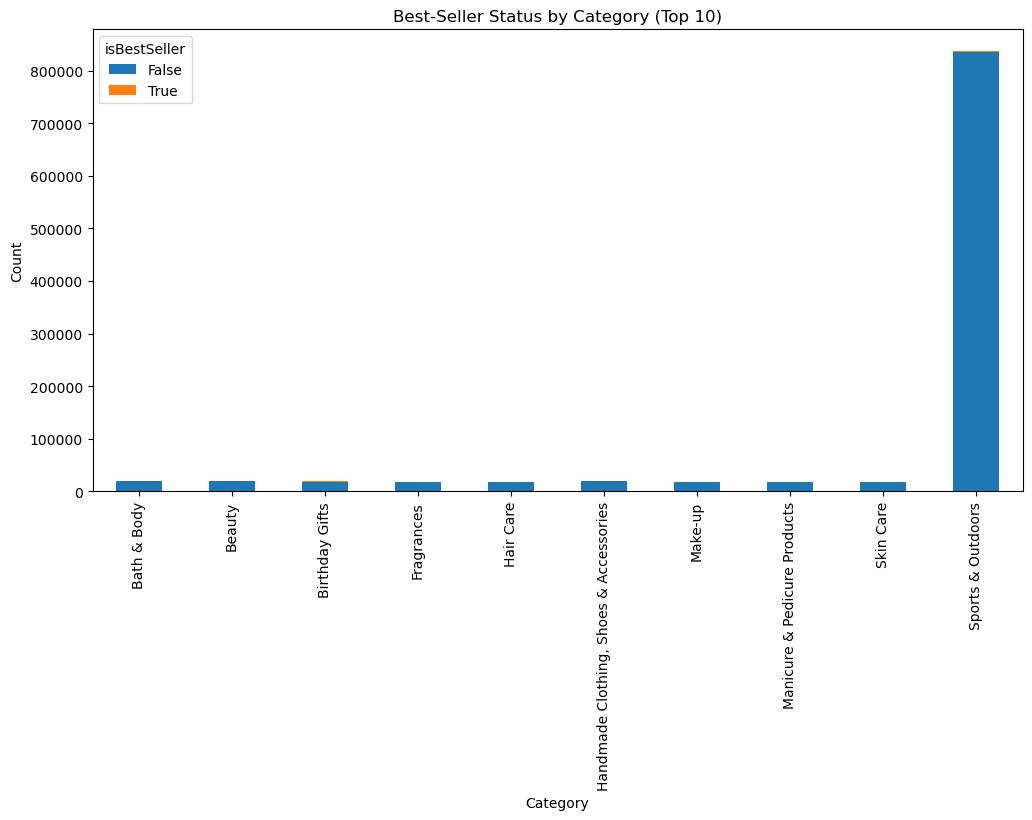

In [6]:
# Stacked Bar Chart (Top 10 Categories for readability)
top_categories = df['category'].value_counts().head(10).index
df_top = df[df['category'].isin(top_categories)]
ct_top = pd.crosstab(df_top['category'], df_top['isBestSeller'])
ct_top.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Best-Seller Status by Category (Top 10)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()


In [7]:
# --- Part 2: Prices and Ratings Across Categories ---
# Remove Price Outliers using IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['price'] >= Q1 - 1.5*IQR) & (df['price'] <= Q3 + 1.5*IQR)]


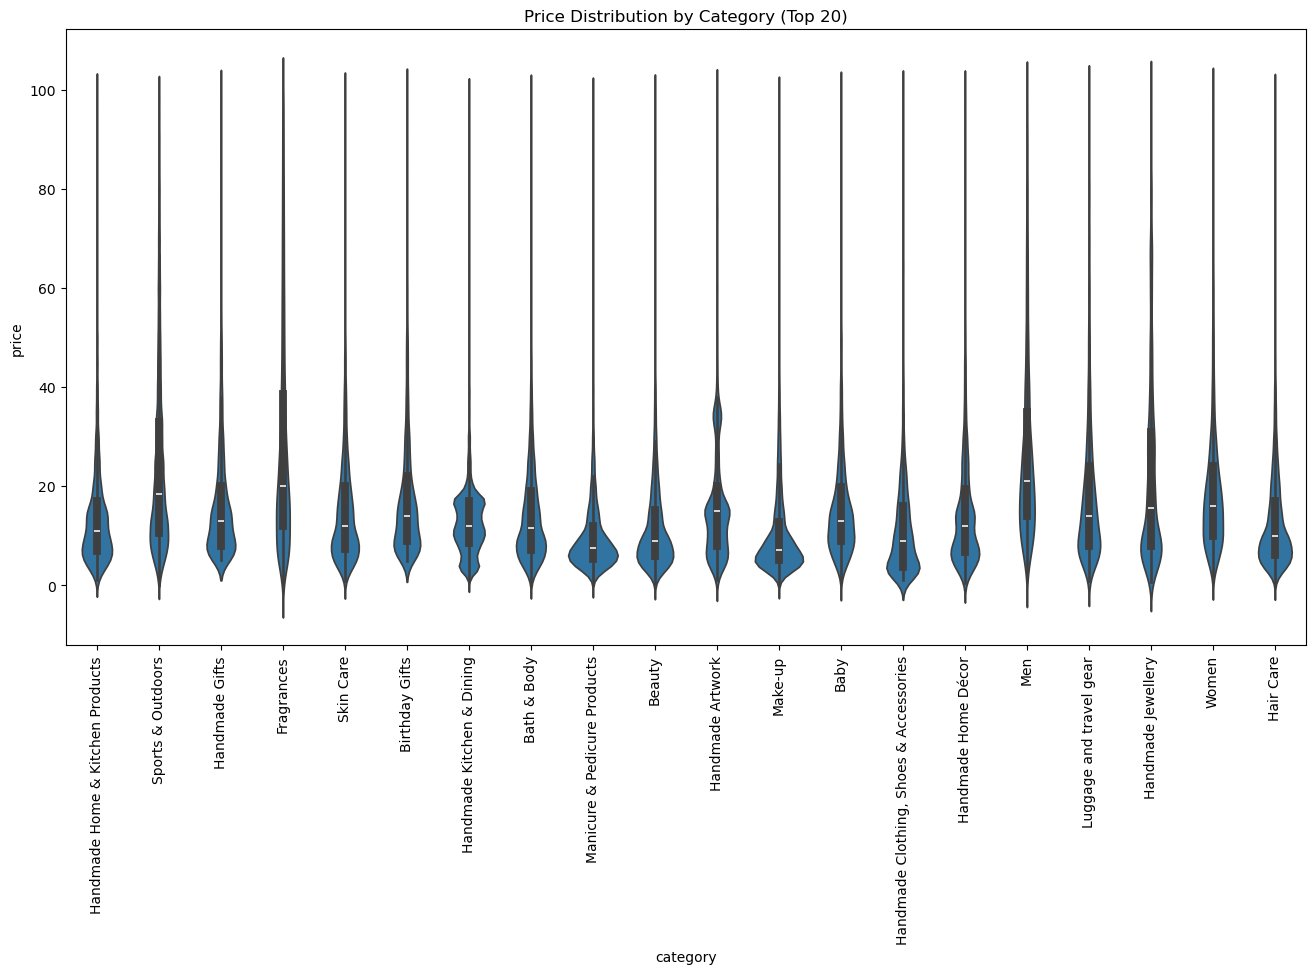

In [8]:

# Violin Plot (Top 20 Categories)
top_20_categories = df_clean['category'].value_counts().head(20).index
df_top20 = df_clean[df_clean['category'].isin(top_20_categories)]
plt.figure(figsize=(16, 8))
sns.violinplot(data=df_top20, x='category', y='price')
plt.xticks(rotation=90)
plt.title('Price Distribution by Category (Top 20)')
plt.show()


In [9]:
# Category with Highest Median Price (Unfiltered)
median_prices = df_clean.groupby('category')['price'].median().sort_values(ascending=False)
print("Category with Highest Median Price:", median_prices.index[0])


Category with Highest Median Price: Desktop PCs


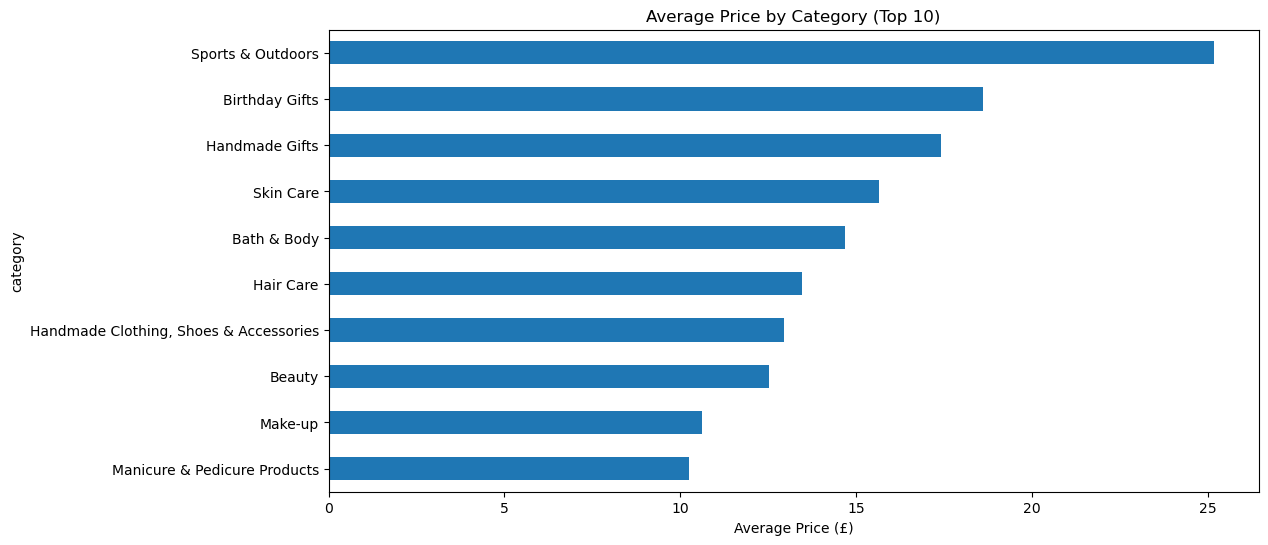

In [10]:
# Bar Chart for Average Price (Top 10 Categories)
top_10_categories = df_clean['category'].value_counts().head(10).index
avg_prices = df_clean[df_clean['category'].isin(top_10_categories)].groupby('category')['price'].mean()
avg_prices.sort_values().plot(kind='barh', figsize=(12, 6))
plt.title('Average Price by Category (Top 10)')
plt.xlabel('Average Price (£)')
plt.show()


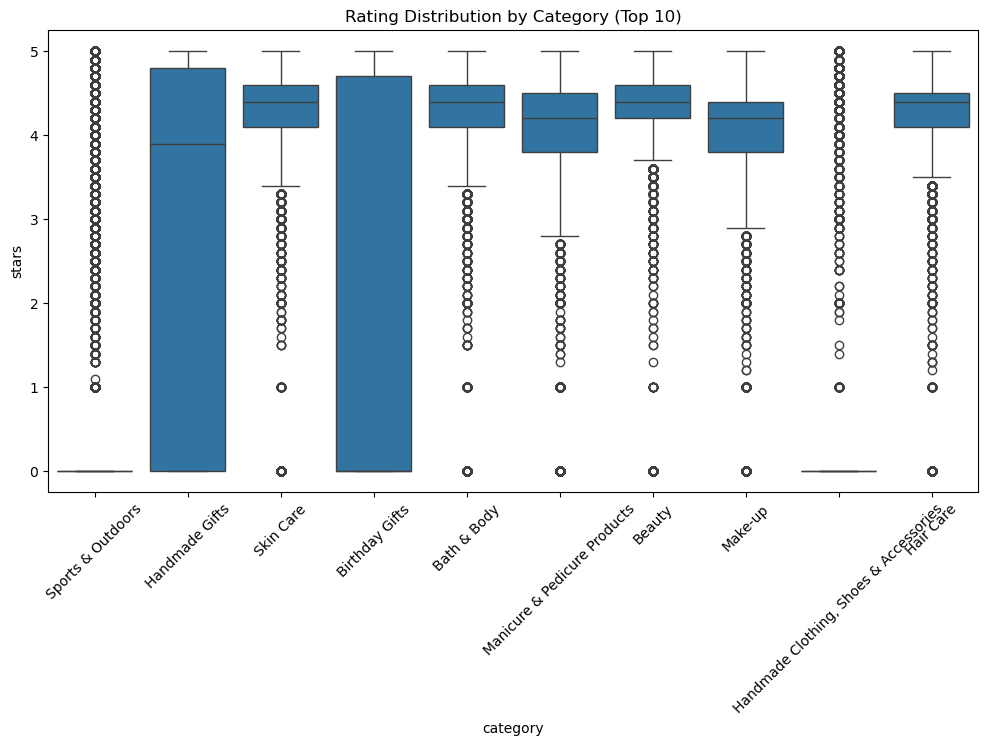

In [12]:
# Box Plot for Ratings (Top 10 Categories)
top_10_rating_categories = df_clean['category'].value_counts().head(10).index
df_rating_top10 = df_clean[df_clean['category'].isin(top_10_rating_categories)]
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_rating_top10, x='category', y='stars')
plt.xticks(rotation=45)
plt.title('Rating Distribution by Category (Top 10)')
plt.show()


In [13]:

# Category with Highest Median Rating (Unfiltered)
median_ratings = df_clean.groupby('category')['stars'].median().sort_values(ascending=False)
print("Category with Highest Median Rating:", median_ratings.index[0])


Category with Highest Median Rating: Computer Memory


In [15]:
# --- Part 3: Price vs Rating Correlation ---
# Correlation Coefficient
corr_coef, p_value = pearsonr(df_clean['price'], df_clean['stars'])
print(f"Correlation between Price and Rating: {corr_coef:.4f} (p = {p_value:.4f})")


Correlation between Price and Rating: -0.0777 (p = 0.0000)


In [ ]:
# Scatter Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_clean, x='price', y='', alpha=0.4)
plt.title('Price vs Rating')
plt.show()
